In [1]:
#Rujuta Sharad Dabke

In [2]:
#Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    StackingClassifier,
    GradientBoostingClassifier,
)
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
)
# Using a whitegrid background for plots
sns.set(style="whitegrid")

In [3]:
MY_CLUSTER_ID = 5
SUBGROUP_FILE = f"cluster_{MY_CLUSTER_ID}_train_data.csv"
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print(f"Cluster ID: {MY_CLUSTER_ID}")
print(f"Input file: {SUBGROUP_FILE}")
print(f"Random seed: {RANDOM_SEED}")

Cluster ID: 5
Input file: cluster_5_train_data.csv
Random seed: 42


In [4]:
import os

if not os.path.isfile(SUBGROUP_FILE):
    raise FileNotFoundError(f"Missing file: {SUBGROUP_FILE}")

df = pd.read_csv(SUBGROUP_FILE)
y = df["Bankrupt?"]
X = df.drop(columns=[c for c in ["Index", "Bankrupt?", "Cluster_ID"] if c in df.columns])

print(f"Loaded {SUBGROUP_FILE}")
print(f"Companies: {len(df)}, Features: {X.shape[1]}")
print("Target distribution:")
print((y.value_counts(normalize=True) * 100).round(2))

Loaded cluster_5_train_data.csv
Companies: 727, Features: 95
Target distribution:
Bankrupt?
0    82.26
1    17.74
Name: proportion, dtype: float64


In [5]:
print("Preprocessing & Feature Selection")

imputer = SimpleImputer(strategy="median")
X_imp = imputer.fit_transform(X)

scaler = StandardScaler()
X_scaled_full = scaler.fit_transform(X_imp)

rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED)
rf.fit(X_scaled_full, y)

selector = SelectFromModel(rf, max_features=35, threshold=-np.inf, prefit=True)
X_scaled = selector.transform(X_scaled_full)

idx = selector.get_support(indices=True)
selected_feature_names = X.columns[idx].tolist()
n_features = X_scaled.shape[1]

print(f"Features retained: {n_features}/{X.shape[1]}")
print(f"Estimated rubric bonus: +{(50 - n_features)/50:.2f}")

Preprocessing & Feature Selection
Features retained: 35/95
Estimated rubric bonus: +0.30


In [6]:
# MODEL TRAINING (Stacking Ensemble)

class ConstantClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, prediction): self.prediction = prediction
    def fit(self, X, y=None): return self
    def predict(self, X): return np.full(X.shape[0], self.prediction, dtype=int)
    def predict_proba(self, X):
        n = X.shape[0]
        return np.column_stack([np.ones(n), np.zeros(n)]) if self.prediction == 0 \
               else np.column_stack([np.zeros(n), np.ones(n)])

unique_classes, class_counts = np.unique(y, return_counts=True)
n_samples = len(y)

print("\nModel training summary:")
for cls, cnt in zip(unique_classes, class_counts):
    print(f"  Class {cls}: {cnt} examples")

if len(unique_classes) < 2:
    print(f"\nSingle-class cluster {MY_CLUSTER_ID}; using ConstantClassifier.")
    clf = ConstantClassifier(prediction=unique_classes[0]).fit(X_scaled, y)
    y_proba = clf.predict_proba(X_scaled)[:, 1]
    best_threshold = 0.5
else:
    print(f"\nTraining stacking ensemble on {n_samples} samples.")
    cv_folds = 5 if n_samples >= 20 else 2
    print(f"Using {cv_folds}-fold CV in stacking.")

    estimators = [
        ("rf", RandomForestClassifier(n_estimators=50, random_state=RANDOM_SEED, class_weight="balanced")),
        ("gb", GradientBoostingClassifier(n_estimators=50, random_state=RANDOM_SEED)),
        ("lr", LogisticRegression(random_state=RANDOM_SEED, class_weight="balanced", max_iter=2000)),
    ]
    clf = StackingClassifier(
        estimators=estimators,
        final_estimator=LogisticRegression(max_iter=2000),
        cv=cv_folds,
        n_jobs=-1
    ).fit(X_scaled, y)

    y_proba = clf.predict_proba(X_scaled)[:, 1]
    print("Stacking ensemble training completed.")


Model training summary:
  Class 0: 598 examples
  Class 1: 129 examples

Training stacking ensemble on 727 samples.
Using 5-fold CV in stacking.
Stacking ensemble training completed.


In [7]:
# THRESHOLD TUNING (Sparsity Constraint)

def eval_th(th):
    yp = (y_proba >= th).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, yp, labels=[0, 1]).ravel()
    sparsity = (tp + fp) / len(y)
    acc_eq1 = tp / (tp + fn) if (tp + fn) else 0
    return dict(threshold=th, tn=tn, fp=fp, fn=fn, tp=tp,
                sparsity=sparsity, acc_eq1=acc_eq1)

best_threshold, best_acc_eq1 = 0.5, -1
thresholds = np.arange(0.1, 0.99, 0.05)

In [8]:
evaluated_candidates = []
for th in thresholds:
    m = eval_th(th)
    evaluated_candidates.append(m)
    if m["sparsity"] < 0.20 and m["acc_eq1"] > best_acc_eq1:
        best_acc_eq1, best_threshold = m["acc_eq1"], th

In [9]:
print("Tuning Probability Threshold")
if best_acc_eq1 < 0:
    print("No threshold in the tested grid satisfies the sparsity < 20% constraint.")
    print("Keeping the default threshold of 0.50.")
else:
    chosen = next(c for c in evaluated_candidates if c["threshold"] == best_threshold)
    print(f"Selected threshold: {best_threshold:.2f}")
    print(f"  Equation 1 accuracy at this threshold : {best_acc_eq1:.3f}")
    print(f"  Positive prediction rate (sparsity)   : {chosen['sparsity']:.3f}")
print("\nTop candidate thresholds by Equation 1 accuracy (sparsity < 0.20):")
for c in sorted(
    [c for c in evaluated_candidates if c["sparsity"] < 0.20],
    key=lambda x: x["acc_eq1"], reverse=True
)[:5]:
    print(
        f"  Threshold {c['threshold']:.2f} | "
        f"Eq1 accuracy: {c['acc_eq1']:.3f} | "
        f"Sparsity: {c['sparsity']:.3f} | "
        f"TP: {c['tp']}, FP: {c['fp']}, FN: {c['fn']}, TN: {c['tn']}"
    )

Tuning Probability Threshold
Selected threshold: 0.30
  Equation 1 accuracy at this threshold : 0.961
  Positive prediction rate (sparsity)   : 0.188

Top candidate thresholds by Equation 1 accuracy (sparsity < 0.20):
  Threshold 0.30 | Eq1 accuracy: 0.961 | Sparsity: 0.188 | TP: 124, FP: 13, FN: 5, TN: 585
  Threshold 0.35 | Eq1 accuracy: 0.930 | Sparsity: 0.173 | TP: 120, FP: 6, FN: 9, TN: 592
  Threshold 0.40 | Eq1 accuracy: 0.884 | Sparsity: 0.158 | TP: 114, FP: 1, FN: 15, TN: 597
  Threshold 0.45 | Eq1 accuracy: 0.822 | Sparsity: 0.146 | TP: 106, FP: 0, FN: 23, TN: 598
  Threshold 0.50 | Eq1 accuracy: 0.752 | Sparsity: 0.133 | TP: 97, FP: 0, FN: 32, TN: 598


In [10]:
# REPORTING (Table 3 Data)

# Final binary predictions using the tuned threshold
y_final_pred = (y_proba >= best_threshold).astype(int)

# Confusion matrix at the chosen threshold
cm = confusion_matrix(y, y_final_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

total_companies = len(y)
actual_bankruptcies = int(sum(y))

# Optional: derive some helpful rates (not required in Table 3 but useful to see)
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0   # recall for bankrupt class
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0   # true negative rate

In [11]:
print("\n" + "=" * 50)
print(f"|| TABLE 3 REPORTING DATA (Cluster {MY_CLUSTER_ID}) ||")
print("=" * 50)
print(f"Subgroup ID:                 {MY_CLUSTER_ID}")
print(f"Total Companies:             {total_companies}")
print(f"Actual Bankruptcies (y=1):   {actual_bankruptcies}")
print("-" * 30)
print("Confusion matrix entries at the chosen threshold:")
print(f"  True Positives  (TT/correctly flagged) : {tp}")
print(f"  False Negatives (TF/missed bankruptcies): {fn}")
print(f"  False Positives (non-bankrupt flagged)  : {fp}")
print(f"  True Negatives  (correctly non-bankrupt): {tn}")
print("-" * 30)
print(f"N_features used in final model:          {n_features}")
print("-" * 30)
print(f"Sensitivity (TPR, y=1)   : {sensitivity:.3f}")
print(f"Specificity (TNR, y=0)   : {specificity:.3f}")
print("=" * 50)


|| TABLE 3 REPORTING DATA (Cluster 5) ||
Subgroup ID:                 5
Total Companies:             727
Actual Bankruptcies (y=1):   129
------------------------------
Confusion matrix entries at the chosen threshold:
  True Positives  (TT/correctly flagged) : 124
  False Negatives (TF/missed bankruptcies): 5
  False Positives (non-bankrupt flagged)  : 13
  True Negatives  (correctly non-bankrupt): 585
------------------------------
N_features used in final model:          35
------------------------------
Sensitivity (TPR, y=1)   : 0.961
Specificity (TNR, y=0)   : 0.978



BASE MODEL PERFORMANCE

--- Evaluating Random Forest ---
TT (Correct): 27
TF (Missed):  102
Equation 1 Accuracy: 20.93%

--- Evaluating Gradient Boosting ---
TT (Correct): 36
TF (Missed):  93
Equation 1 Accuracy: 27.91%

--- Evaluating Logistic Regression ---
TT (Correct): 91
TF (Missed):  38
Equation 1 Accuracy: 70.54%


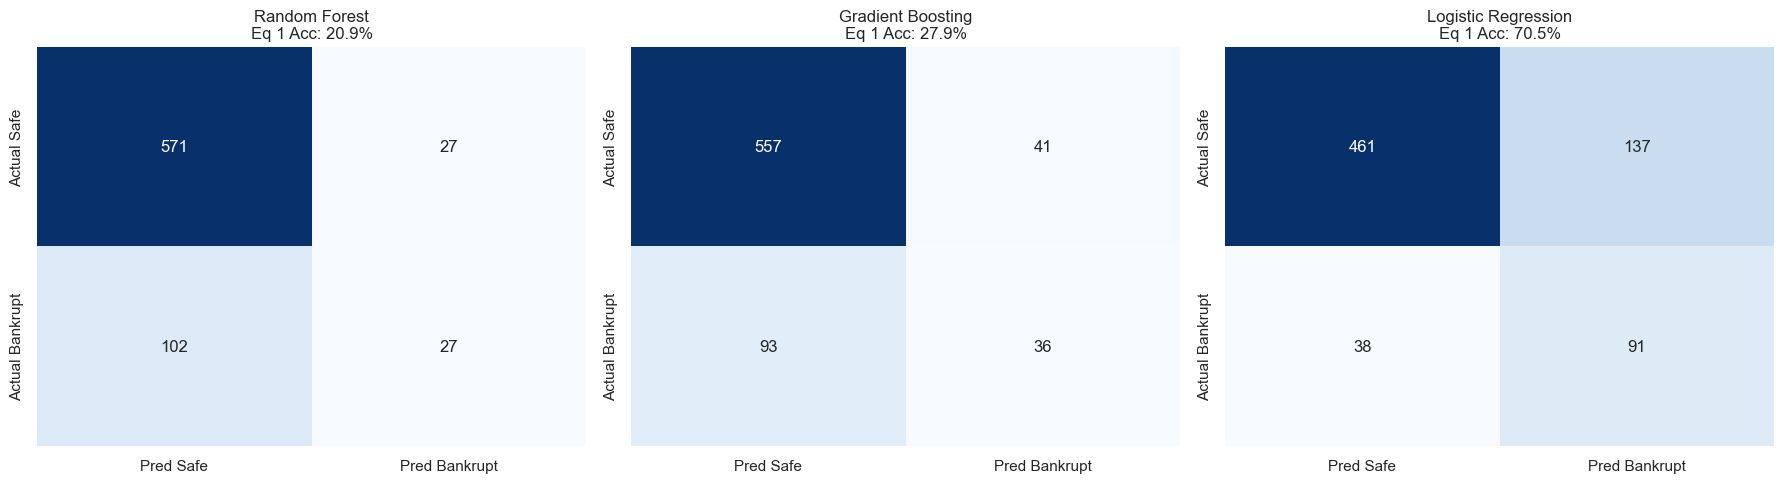

In [12]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix

print("\nBASE MODEL PERFORMANCE")

base_models = [
    ("Random Forest", RandomForestClassifier(n_estimators=50, random_state=RANDOM_SEED, class_weight="balanced")),
    ("Gradient Boosting", GradientBoostingClassifier(n_estimators=50, random_state=RANDOM_SEED)),
    ("Logistic Regression", LogisticRegression(random_state=RANDOM_SEED, class_weight="balanced", max_iter=2000)),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, model) in zip(axes, base_models):
    print(f"\n--- Evaluating {name} ---")
    try:
        y_pred_base = cross_val_predict(model, X_scaled, y, cv=5, n_jobs=-1)
        tn, fp, fn, tp = confusion_matrix(y, y_pred_base, labels=[0, 1]).ravel()
        total_bankrupt = tp + fn
        acc_eq1 = tp / total_bankrupt if total_bankrupt > 0 else 0

        print(f"TT (Correct): {tp}")
        print(f"TF (Missed):  {fn}")
        print(f"Equation 1 Accuracy: {acc_eq1:.2%}")

        cm_base = np.array([[tn, fp], [fn, tp]])
        sns.heatmap(
            cm_base,
            annot=True,
            fmt="d",
            cmap="Blues",
            cbar=False,
            xticklabels=["Pred Safe", "Pred Bankrupt"],
            yticklabels=["Actual Safe", "Actual Bankrupt"],
            ax=ax,
        )
        ax.set_title(f"{name}\nEq 1 Acc: {acc_eq1:.1%}")
    except ValueError:
        print(f"Skipping {name}: Cluster too small.")

plt.tight_layout()
plt.show()

In [13]:
# SAVE INDIVIDUAL MODEL
# Bundle all required components for inference and reproducibility
model_bundle = {
    'model': clf,
    'scaler': scaler,
    'imputer': imputer,
    'threshold': best_threshold,
    'features': selected_feature_names  # stores the final selected feature set
}

# Construct the output file name based on the cluster ID
filename = f'member_model_cluster_{MY_CLUSTER_ID}.joblib'

# Persist the model bundle to disk
joblib.dump(model_bundle, filename)

['member_model_cluster_5.joblib']

In [14]:
# Clear, descriptive confirmation output
print("Model bundle saved successfully.")
print(f"Saved file name      : {filename}")
print("Included components : model, scaler, imputer, threshold, selected features")
print("This file can be loaded later for consistent inference or evaluation.\n")

Model bundle saved successfully.
Saved file name      : member_model_cluster_5.joblib
Included components : model, scaler, imputer, threshold, selected features
This file can be loaded later for consistent inference or evaluation.




[ROC Curve: Stacking vs Base Model]
Purpose: Compare how well the stacking model and a baseline Random Forest
         rank companies from lowest to highest bankruptcy risk (AUC).


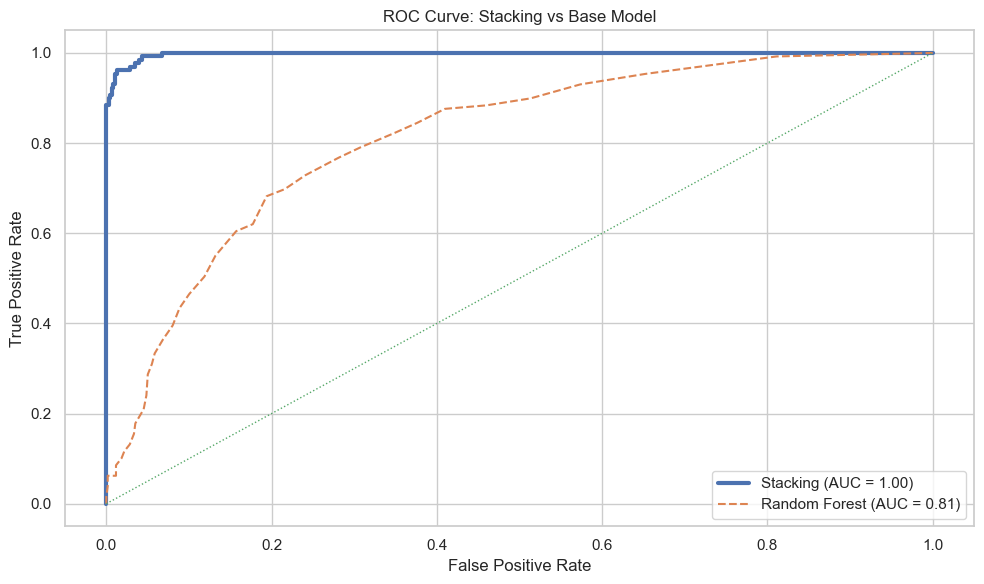

In [15]:
# ROC Curve: Stacking vs Base (only if both classes exist)
if len(unique_classes) > 1:
    print("\n[ROC Curve: Stacking vs Base Model]")
    print("Purpose: Compare how well the stacking model and a baseline Random Forest")
    print("         rank companies from lowest to highest bankruptcy risk (AUC).")

    fig, ax = plt.subplots(figsize=(10, 6))

    fpr, tpr, _ = roc_curve(y, y_proba)
    ax.plot(fpr, tpr, label=f"Stacking (AUC = {auc(fpr, tpr):.2f})", linewidth=3)

    try:
        rf_base = RandomForestClassifier(
            n_estimators=50,
            random_state=RANDOM_SEED,
            class_weight="balanced"
        )
        y_rf = cross_val_predict(
            rf_base, X_scaled, y,
            cv=5, method="predict_proba", n_jobs=-1
        )[:, 1]
        fpr_b, tpr_b, _ = roc_curve(y, y_rf)
        ax.plot(fpr_b, tpr_b, "--", label=f"Random Forest (AUC = {auc(fpr_b, tpr_b):.2f})")
    except Exception:
        print("Warning: baseline ROC curve for Random Forest could not be computed.")

    ax.plot([0, 1], [0, 1], ":", linewidth=1)
    ax.set(
        title="ROC Curve: Stacking vs Base Model",
        xlabel="False Positive Rate",
        ylabel="True Positive Rate"
    )
    ax.legend(loc="lower right")
    plt.tight_layout()
    plt.show()


[Key Cluster Characteristics (Top 3 Features)]
Purpose: Show how the most important features differ between
         bankrupt and non-bankrupt companies in this cluster.


/var/folders/jn/7q4k5xqj6tdc7t0t0_c17hrm0000gn/T/ipykernel_67220/1458360230.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=y, y=X[feat], ax=ax, palette="Set2", cut=0)
/var/folders/jn/7q4k5xqj6tdc7t0t0_c17hrm0000gn/T/ipykernel_67220/1458360230.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=y, y=X[feat], ax=ax, palette="Set2", cut=0)
/var/folders/jn/7q4k5xqj6tdc7t0t0_c17hrm0000gn/T/ipykernel_67220/1458360230.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=y, y=X[feat], ax=ax, palette="Set2", cut=0)


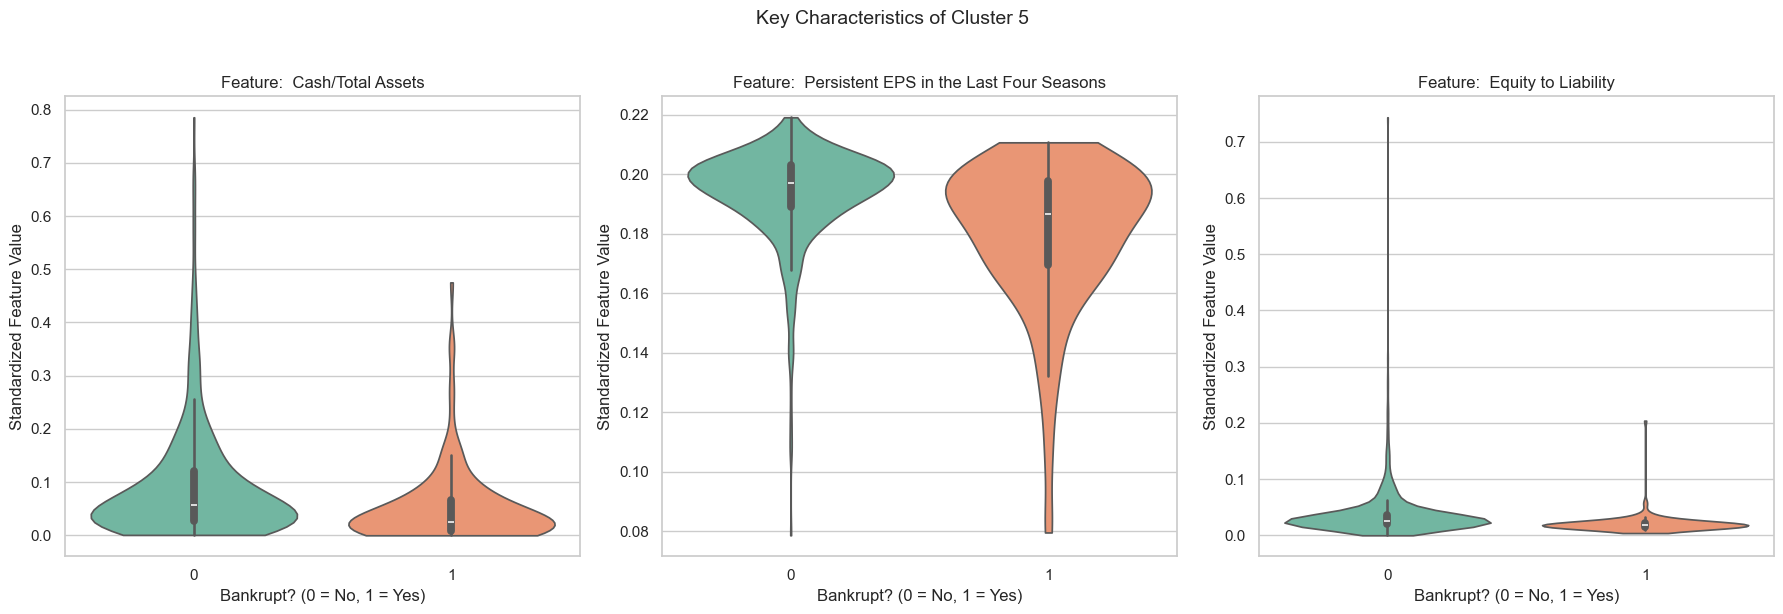


Analysis complete.


In [16]:
# Key Cluster Characteristics (Top 3 Features)
if len(unique_classes) > 1:
    print("\n[Key Cluster Characteristics (Top 3 Features)]")
    print("Purpose: Show how the most important features differ between")
    print("         bankrupt and non-bankrupt companies in this cluster.")

    rf_selector = RandomForestClassifier(n_estimators=50, random_state=RANDOM_SEED)
    rf_selector.fit(X_scaled, y)

    top_3 = (
        pd.Series(rf_selector.feature_importances_, index=selected_feature_names)
        .nlargest(3)
        .index
    )

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    for ax, feat in zip(axes, top_3):
        sns.violinplot(x=y, y=X[feat], ax=ax, palette="Set2", cut=0)
        ax.set_title(f"Feature: {feat}")
        ax.set_xlabel("Bankrupt? (0 = No, 1 = Yes)")
        ax.set_ylabel("Standardized Feature Value")

    fig.suptitle(f"Key Characteristics of Cluster {MY_CLUSTER_ID}", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

print("\nAnalysis complete.")


Class Balance Visualization


/var/folders/jn/7q4k5xqj6tdc7t0t0_c17hrm0000gn/T/ipykernel_67220/2119699488.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


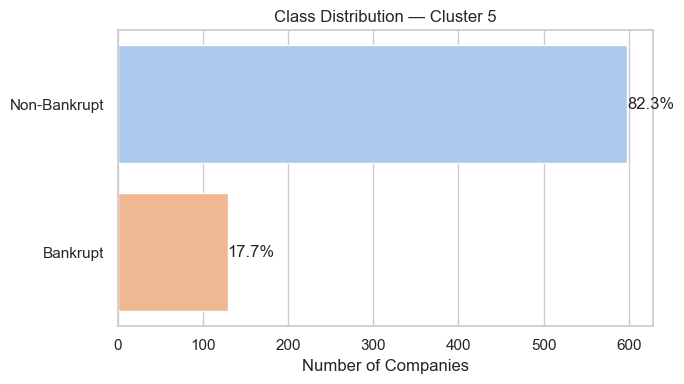

In [17]:
print("\nClass Balance Visualization")

counts = y.value_counts().reindex([0, 1], fill_value=0)
pct = counts / len(y) * 100

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(
    x=counts.values,
    y=["Non-Bankrupt", "Bankrupt"],
    palette="pastel",
    ax=ax
)

ax.set_title(f"Class Distribution — Cluster {MY_CLUSTER_ID}")
ax.set_xlabel("Number of Companies")

for i, v in enumerate(counts.values):
    ax.text(v, i, f"{pct.iloc[i]:.1f}%", va="center")

plt.tight_layout()
plt.show()


Correlation Heatmap (Top 20 features)


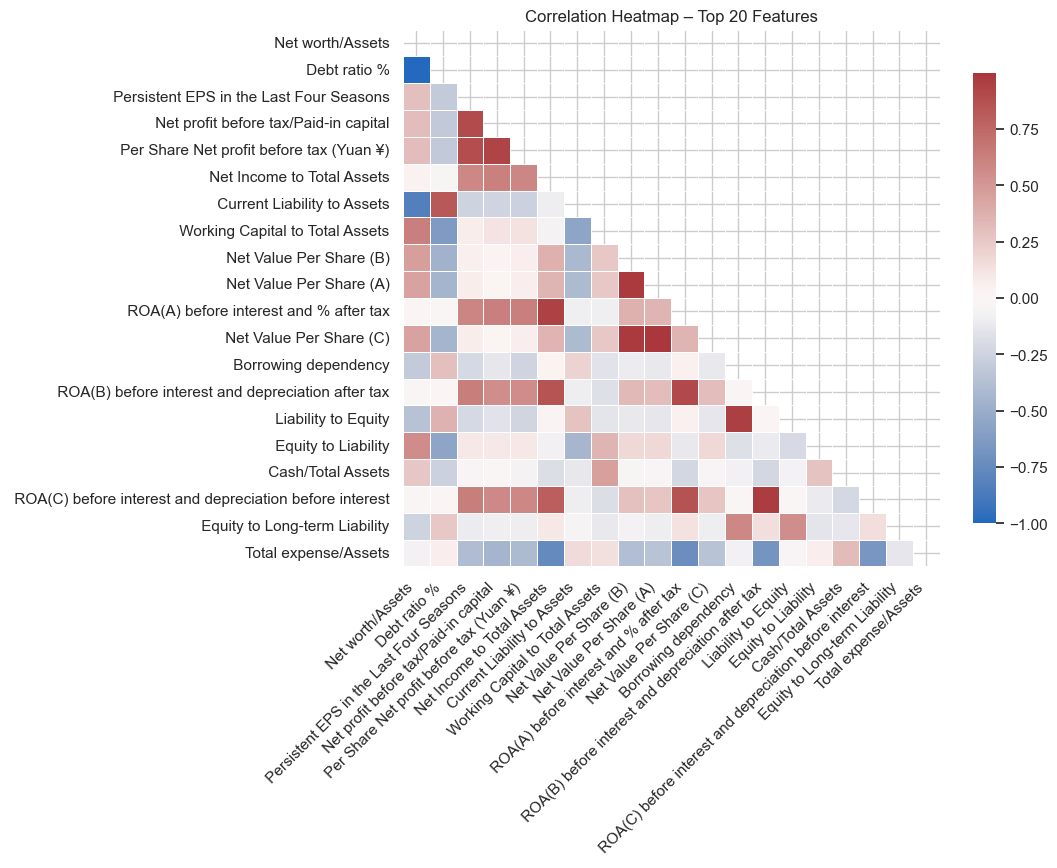

In [18]:
print("\nCorrelation Heatmap (Top 20 features)")

df_corr = pd.concat([X, y.rename("Bankrupt?")], axis=1).corr()
top_feats = (
    df_corr["Bankrupt?"].abs()
    .drop("Bankrupt?")
    .sort_values(ascending=False)
    .head(20)
    .index
)

corr_top = df_corr.loc[top_feats, top_feats]
mask = np.triu(np.ones_like(corr_top, dtype=bool))

plt.figure(figsize=(11, 9))
sns.heatmap(
    corr_top,
    mask=mask,
    cmap="vlag",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Heatmap – Top 20 Features")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


PCA Scree Plot and 2D Projection


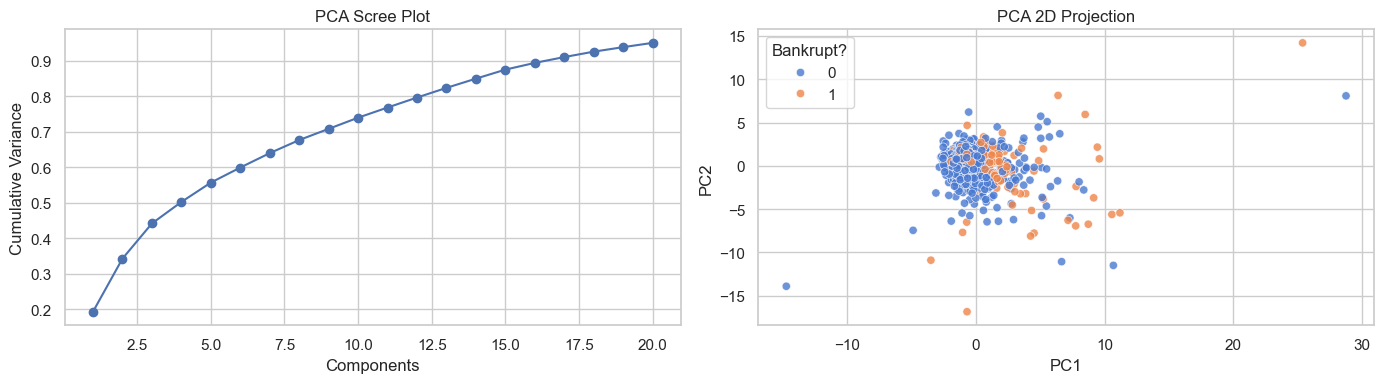

In [19]:
print("\nPCA Scree Plot and 2D Projection")

from sklearn.decomposition import PCA

pca = PCA(n_components=min(20, X_scaled.shape[1]), random_state=RANDOM_SEED)
cum_var = pca.fit(X_scaled).explained_variance_ratio_.cumsum()

fig, ax = plt.subplots(1, 2, figsize=(14, 4))

ax[0].plot(range(1, len(cum_var) + 1), cum_var, marker="o")
ax[0].set(title="PCA Scree Plot", xlabel="Components", ylabel="Cumulative Variance")

pca2 = PCA(n_components=2, random_state=RANDOM_SEED).fit_transform(X_scaled)
sns.scatterplot(x=pca2[:, 0], y=pca2[:, 1], hue=y, ax=ax[1], palette="muted", alpha=0.8)
ax[1].set(title="PCA 2D Projection", xlabel="PC1", ylabel="PC2")

plt.tight_layout()
plt.show()



Feature Importance Visualization


/var/folders/jn/7q4k5xqj6tdc7t0t0_c17hrm0000gn/T/ipykernel_67220/2501057002.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(fi_top.index, rotation=45, ha="right")


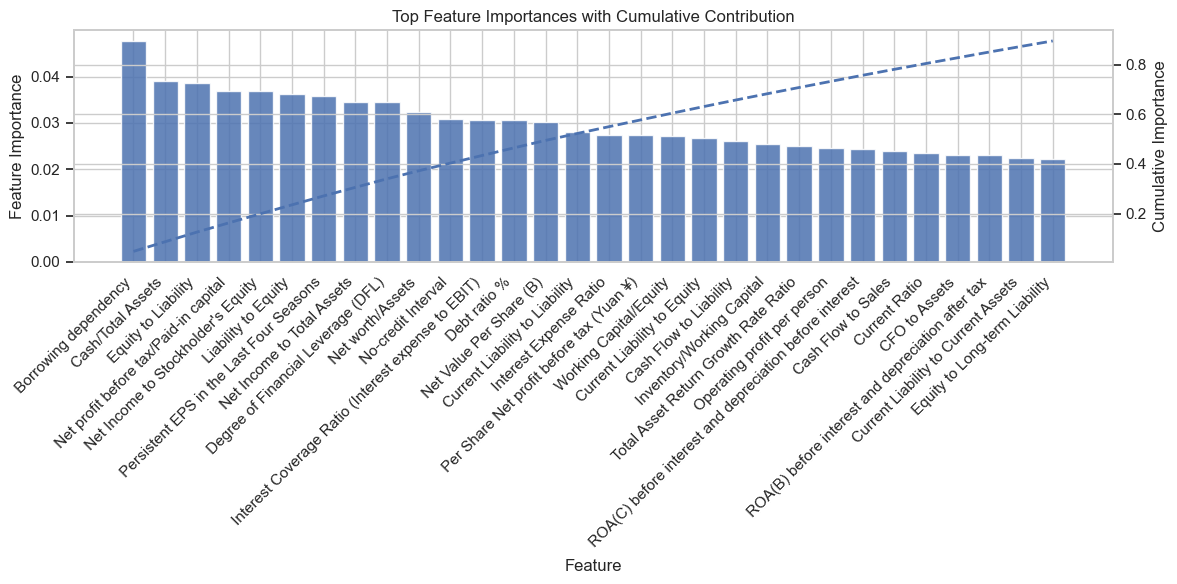

In [20]:
print("\nFeature Importance Visualization")

rf_tmp = RandomForestClassifier(n_estimators=200, random_state=RANDOM_SEED)
rf_tmp.fit(X_scaled, y)

fi = pd.Series(rf_tmp.feature_importances_, index=selected_feature_names).sort_values(ascending=False)
fi_top = fi.head(30)
cum = fi.cumsum().head(30)

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.bar(fi_top.index, fi_top.values, alpha=0.85)
ax1.set_ylabel("Feature Importance")
ax1.set_xlabel("Feature")
ax1.set_xticklabels(fi_top.index, rotation=45, ha="right")
ax1.set_title("Top Feature Importances with Cumulative Contribution")

ax2 = ax1.twinx()
ax2.plot(fi_top.index, cum.values, linestyle="--", linewidth=2)
ax2.set_ylabel("Cumulative Importance")

plt.tight_layout()
plt.show()


Precision–Recall Curve


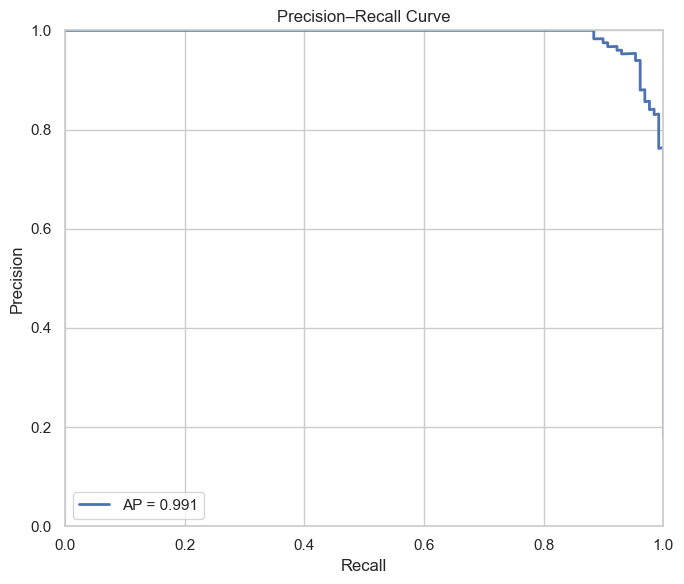

In [21]:
print("\nPrecision–Recall Curve")

from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(y, y_proba)
avg_prec = average_precision_score(y, y_proba)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(recall, precision, label=f"AP = {avg_prec:.3f}", linewidth=2)
ax.set(title="Precision–Recall Curve", xlabel="Recall", ylabel="Precision",
       xlim=(0, 1), ylim=(0, 1))
ax.legend(loc="lower left")

plt.tight_layout()
plt.show()


Calibration Diagnostics


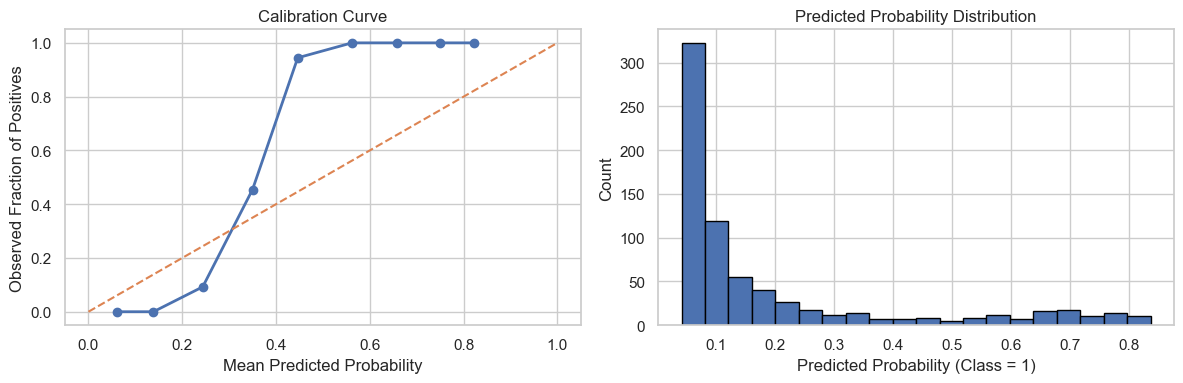

In [22]:
print("\nCalibration Diagnostics")

from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y, y_proba, n_bins=10)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(prob_pred, prob_true, "o-", linewidth=2)
ax[0].plot([0, 1], [0, 1], "--")
ax[0].set(title="Calibration Curve",
          xlabel="Mean Predicted Probability",
          ylabel="Observed Fraction of Positives")

ax[1].hist(y_proba, bins=20, edgecolor="black")
ax[1].set(title="Predicted Probability Distribution",
          xlabel="Predicted Probability (Class = 1)",
          ylabel="Count")

plt.tight_layout()
plt.show()

In [23]:
print("\nInspection of Top False Negatives")

y_pred = (y_proba >= best_threshold).astype(int)
tn, fp, fn, tp = confusion_matrix(y, y_pred, labels=[0, 1]).ravel()

print(f"\nConfusion matrix at threshold {best_threshold:.2f}:")
print(f"TN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}")

if fn > 0:
    idx_fn = np.where((y == 1) & (y_pred == 0))[0]
    hardest = idx_fn[np.argsort(y_proba[idx_fn])][:5]
    df_fn = X.iloc[hardest][selected_feature_names].copy()
    df_fn["pred_prob"] = y_proba[hardest]
    df_fn["actual"] = y.iloc[hardest].values
    display(df_fn)
else:
    print("\nNo false negatives found at the chosen threshold.")


Inspection of Top False Negatives

Confusion matrix at threshold 0.30:
TN: 585, FP: 13, FN: 5, TP: 124


,ROA(C) before interest and depreciation before interest,ROA(B) before interest and depreciation after tax,Net Value Per Share (B),Net Value Per Share (A),Persistent EPS in the Last Four Seasons,Per Share Net profit before tax (Yuan ¥),Total Asset Return Growth Rate Ratio,Cash Reinvestment %,Current Ratio,Interest Expense Ratio,...,Current Liability to Current Assets,Net Income to Total Assets,No-credit Interval,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Equity to Liability,pred_prob,actual
687,0.443524,0.496440,0.172222,0.172222,0.199489,0.157490,0.263722,0.376495,0.008995,0.629847,...,0.032374,0.767153,0.622145,0.837976,0.278401,0.026603,0.564065,0.036259,0.233191,1
226,0.397894,0.363778,0.139016,0.139016,0.198355,0.159223,0.265397,0.365132,0.017131,0.630611,...,0.017124,0.627605,0.624102,0.829992,0.276669,0.026791,0.565156,0.058930,0.255389,1
281,0.417540,0.460892,0.173655,0.173655,0.189846,0.148528,0.262900,0.368317,0.015661,0.629741,...,0.018729,0.754696,0.624491,0.836693,0.279759,0.026550,0.563668,0.029296,0.268076,1
715,0.430264,0.482574,0.165985,0.165985,0.197599,0.156436,0.263714,0.374483,0.006381,0.630166,...,0.045152,0.772905,0.623405,0.837797,0.282100,0.026688,0.564613,0.023280,0.283143,1
38,0.407839,0.454735,0.151995,0.151995,0.197315,0.156361,0.263583,0.361341,0.008015,0.630347,...,0.036224,0.745256,0.623773,0.835866,0.279932,0.026714,0.564760,0.028667,0.292254,1
